### H2O AutoML Repeat

In [6]:
import os
import sys
import time
from pathlib import Path

os.environ.setdefault("KMP_DUPLICATE_LIB_OK", "TRUE")

# Project root is one level above notebooks/
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

import h2o
import mlflow
import numpy as np
import pandas as pd
from h2o.automl import H2OAutoML
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import config
from preprocess import get_feature_matrix, load_and_clean, train_test_split_xy

config.REPORTS_DIR.mkdir(parents=True, exist_ok=True)
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

mlflow.set_tracking_uri(config.MLFLOW_TRACKING_URI)
mlflow.set_experiment(config.MLFLOW_EXPERIMENT_NAME)

<Experiment: artifact_location=('file:///Users/collinkim/Documents/UChicago ADS/Summer '
 '2026/MLOps/Assignments/mlops_assign3/mlruns/476840276799339422'), creation_time=1785203142924, experiment_id='476840276799339422', last_update_time=1785203142924, lifecycle_stage='active', name='athlete_total_lift_automl', tags={}>

### Setup

In [7]:
clean = load_and_clean()
X, y, feature_cols = get_feature_matrix(clean, config.ALL_FEATURES)
X_train, X_test, y_train, y_test = train_test_split_xy(X, y)

train_df = X_train.copy()
train_df[config.TARGET] = y_train.values
test_df = X_test.copy()
test_df[config.TARGET] = y_test.values

print("Features:", feature_cols)
print("Train:", train_df.shape, "| Test:", test_df.shape)

Features: ['age', 'height', 'weight', 'gender_male', 'is_experienced', 'has_athletic_background']
Train: (37648, 7) | Test: (9413, 7)


### H2O AutoML (all features)

In [8]:
# #region agent log
import json, shutil, socket, subprocess
_DBG = "/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/.cursor/debug-085a1f.log"
def _agent_log(hid, msg, data, run_id="post-fix"):
    with open(_DBG, "a") as f:
        f.write(json.dumps({"sessionId": "085a1f", "runId": run_id, "hypothesisId": hid, "location": "h2o_automl.ipynb:h2o.init", "message": msg, "data": data, "timestamp": int(time.time() * 1000)}) + "\n")
_which = shutil.which("java")
_jh = os.environ.get("JAVA_HOME")
_brew = "/opt/homebrew/opt/openjdk@17/bin/java"
_stub_out, _stub_rc = "", None
try:
    _p = subprocess.run([_which or "/usr/bin/java", "-version"], capture_output=True, text=True)
    _stub_out = (_p.stderr or _p.stdout or "")[:300]
    _stub_rc = _p.returncode
except Exception as _e:
    _stub_out, _stub_rc = str(_e), -1
_brew_out, _brew_rc, _brew_exists = "", None, os.path.exists(_brew)
if _brew_exists:
    try:
        _p = subprocess.run([_brew, "-version"], capture_output=True, text=True)
        _brew_out = (_p.stderr or _p.stdout or "")[:300]
        _brew_rc = _p.returncode
    except Exception as _e:
        _brew_out, _brew_rc = str(_e), -1
_port_open = False
try:
    _s = socket.create_connection(("127.0.0.1", 54321), timeout=1)
    _s.close(); _port_open = True
except OSError:
    _port_open = False
_agent_log("A", "path-java-version-before-fix", {"which_java": _which, "returncode": _stub_rc, "output": _stub_out})
_agent_log("B", "java-home-before-fix", {"JAVA_HOME": _jh, "PATH_has_openjdk17": "/opt/homebrew/opt/openjdk@17" in os.environ.get("PATH", "")})
_agent_log("C", "brew-openjdk17", {"exists": _brew_exists, "returncode": _brew_rc, "output": _brew_out})
_agent_log("D", "h2o-port-54321", {"port_open": _port_open})
# #endregion

# H2O needs a real JDK; macOS /usr/bin/java is a stub. Prefer Homebrew OpenJDK 17.
_JAVA_HOME_CANDIDATES = [
    Path("/opt/homebrew/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
    Path("/usr/local/opt/openjdk@17/libexec/openjdk.jdk/Contents/Home"),
]
if not os.environ.get("JAVA_HOME"):
    for _cand in _JAVA_HOME_CANDIDATES:
        if (_cand / "bin" / "java").exists():
            os.environ["JAVA_HOME"] = str(_cand)
            os.environ["PATH"] = f"{_cand / 'bin'}{os.pathsep}{os.environ.get('PATH', '')}"
            break

# #region agent log
_which2 = shutil.which("java")
_p2 = subprocess.run([_which2 or "java", "-version"], capture_output=True, text=True)
_agent_log("E", "java-after-path-fix", {
    "JAVA_HOME": os.environ.get("JAVA_HOME"),
    "which_java": _which2,
    "returncode": _p2.returncode,
    "output": ((_p2.stderr or _p2.stdout) or "")[:300],
})
# #endregion

h2o.init()

# #region agent log
_agent_log("E", "h2o-init-succeeded", {"connected": True, "cluster": str(h2o.cluster())})
# #endregion

train_h2o = h2o.H2OFrame(train_df)
test_h2o = h2o.H2OFrame(test_df)

x = feature_cols
y_col = config.TARGET

aml = H2OAutoML(
    max_runtime_secs=config.H2O_MAX_RUNTIME_SECS,
    max_models=config.H2O_MAX_MODELS,
    nfolds=config.H2O_NFOLDS,
    seed=config.SEED,
    sort_metric="RMSE",
)

t0 = time.perf_counter()
aml.train(x=x, y=y_col, training_frame=train_h2o)
h2o_fit_seconds = time.perf_counter() - t0

best = aml.leader
print("Best model:", best.model_id)
print(f"H2O AutoML wall-clock (s): {h2o_fit_seconds:.1f}")


Checking whether there is an H2O instance running at http://localhost:54321..... not found.
Attempting to start a local H2O server...
  Java Version: openjdk version "17.0.20" 2026-07-21; OpenJDK Runtime Environment Homebrew (build 17.0.20+0); OpenJDK 64-Bit Server VM Homebrew (build 17.0.20+0, mixed mode, sharing)
  Starting server from /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/h2o/backend/bin/h2o.jar
  Ice root: /var/folders/h6/qh4xdv4n6ld89l43j3kxvdd40000gn/T/tmpyk49iir9
  JVM stdout: /var/folders/h6/qh4xdv4n6ld89l43j3kxvdd40000gn/T/tmpyk49iir9/h2o_collinkim_started_from_python.out
  JVM stderr: /var/folders/h6/qh4xdv4n6ld89l43j3kxvdd40000gn/T/tmpyk49iir9/h2o_collinkim_started_from_python.err
  Server is running at http://127.0.0.1:54321
Connecting to H2O server at http://127.0.0.1:54321 ... successful.
Please download and install the latest version from: https://h2o-release.s3.amazonaws.com/h2o/latest_stabl

H2O_cluster_uptime:,01 secs
H2O_cluster_timezone:,America/Chicago
H2O_data_parsing_timezone:,UTC
H2O_cluster_version:,3.46.0.6
H2O_cluster_version_age:,"1 year, 8 months and 26 days"
H2O_cluster_name:,H2O_from_python_collinkim_8bzeje
H2O_cluster_total_nodes:,1
H2O_cluster_free_memory:,4 Gb
H2O_cluster_total_cores:,10
H2O_cluster_allowed_cores:,10
H2O_cluster_status:,"locked, healthy"


Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
Parse progress: |████████████████████████████████████████████████████████████████| (done) 100%
AutoML progress: |
12:22:03.224: AutoML: XGBoost is not available; skipping it.

███████████████████████████████████████████████████████████████| (done) 100%
Best model: GBM_5_AutoML_1_20260728_122203
H2O AutoML wall-clock (s): 181.6


In [9]:
# Leaderboard
lb = aml.leaderboard.as_data_frame()
lb.index = np.arange(1, len(lb) + 1)
lb.index.name = "rank"
leaderboard_path = config.REPORTS_DIR / "h2o_leaderboard_all.csv"
lb.to_csv(leaderboard_path)

print("Top 3 models by validation score (RMSE):")
display(lb.head(3))

Top 3 models by validation score (RMSE):


/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


,model_id,rmse,mse,mae,rmsle,mean_residual_deviance
rank,,,,,,
1,GBM_5_AutoML_1_20260728_122203,155.256346,24104.533068,119.152892,0.192047,24104.533068
2,GBM_grid_1_AutoML_1_20260728_122203_model_12,155.353999,24134.864888,119.201704,0.192162,24134.864888
3,GBM_2_AutoML_1_20260728_122203,155.366106,24138.626994,119.262252,0.192168,24138.626994


In [10]:
# Holdout metrics on the same 20% test set used for TPOT
preds = best.predict(test_h2o).as_data_frame()
y_pred = preds.iloc[:, 0].values
h2o_rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
h2o_mae = float(mean_absolute_error(y_test, y_pred))
h2o_r2 = float(r2_score(y_test, y_pred))

print(f"\nHoldout RMSE: {h2o_rmse:.4f}")
print(f"Holdout MAE:  {h2o_mae:.4f}")
print(f"Holdout R2:   {h2o_r2:.4f}")
print(f"Wrote {leaderboard_path}")

gbm prediction progress: |███████████████████████████████████████████████████████| (done) 100%

Holdout RMSE: 156.7732
Holdout MAE:  120.0366
Holdout R2:   0.6869
Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/h2o_leaderboard_all.csv


/Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/.venv/lib/python3.9/site-packages/h2o/frame.py:1983: H2ODependencyWarning: Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using multi-thread, install polars and pyarrow and use it as pandas_df = h2o_df.as_data_frame(use_multi_thread=True)

  warnings.warn("Converting H2O frame to pandas dataframe using single-thread.  For faster conversion using"


## Data insights and top-5 features (`varimp`)

In [11]:
import matplotlib.pyplot as plt

# Prefer a model with variable importance
varimp_model = best
vi = None
try:
    vi = varimp_model.varimp(use_pandas=True)
except Exception:
    vi = None

if vi is None or len(vi) == 0:
    for mid in lb["model_id"].tolist():
        if "StackedEnsemble" in mid:
            continue
        m = h2o.get_model(mid)
        try:
            vi = m.varimp(use_pandas=True)
        except Exception:
            vi = None
        if vi is not None and len(vi) > 0:
            varimp_model = m
            print(f"Using varimp from non-ensemble model: {mid}")
            break

if vi is None or len(vi) == 0:
    raise RuntimeError("Could not extract variable importance from H2O models")

vi = vi.rename(columns={"variable": "feature", "relative_importance": "relative_importance",
                         "scaled_importance": "scaled_importance", "percentage": "percentage"})
vi = vi.reset_index(drop=True)
vi.index = vi.index + 1
vi.index.name = "rank"

importance_path = config.REPORTS_DIR / "h2o_feature_importance.csv"
vi.to_csv(importance_path)

print("Top 5 features (H2O varimp):")
display(vi.head(5))

Top 5 features (H2O varimp):


,feature,relative_importance,scaled_importance,percentage
rank,,,,
1,gender_male,5.726648e+09,1.000000,0.569750
2,height,1.877491e+09,0.327852,0.186793
3,weight,1.387582e+09,0.242303,0.138052
4,age,5.374614e+08,0.093853,0.053473
5,is_experienced,3.224523e+08,0.056307,0.032081


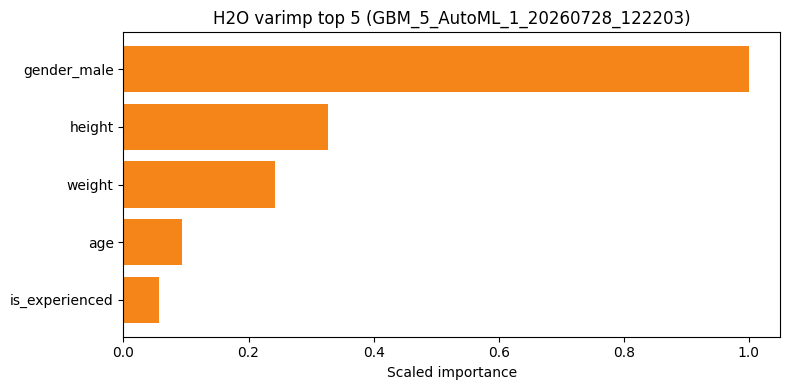

Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/h2o_feature_importance.csv
Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/figures/h2o_feature_importance.png

Insight: physical / demographic features (weight, gender, height, age) should dominate if H2O agrees with TPOT.


In [12]:
fig, ax = plt.subplots(figsize=(8, 4))
plot_df = vi.head(5).iloc[::-1]
ax.barh(plot_df["feature"], plot_df["scaled_importance"], color="#F58518")
ax.set_xlabel("Scaled importance")
ax.set_title(f"H2O varimp top 5 ({varimp_model.model_id})")
fig.tight_layout()
fig_path = config.FIGURES_DIR / "h2o_feature_importance.png"
fig.savefig(fig_path, dpi=150)
plt.show()

print(f"Wrote {importance_path}")
print(f"Wrote {fig_path}")
print("\nInsight: physical / demographic features (weight, gender, height, age) should dominate if H2O agrees with TPOT.")

### Compare H2O vs TPOT

In [13]:
tpot_cmp_path = config.REPORTS_DIR / "baseline_vs_tpot.csv"
if tpot_cmp_path.exists():
    prior = pd.read_csv(tpot_cmp_path)
    # Be robust to slight label wording differences
    mask = prior["model"].astype(str).str.contains(r"TPOT.*all", case=False, regex=True)
    if not mask.any():
        raise KeyError(f"No TPOT all-features row in {tpot_cmp_path}. Found: {prior['model'].tolist()}")
    tpot_all = prior.loc[mask].iloc[0]
    tpot_rmse = float(tpot_all["holdout_rmse"])
    tpot_mae = float(tpot_all["holdout_mae"])
    tpot_r2 = float(tpot_all["holdout_r2"])
    tpot_secs = float(tpot_all["fit_or_search_seconds"])
else:
    tpot_rmse, tpot_mae, tpot_r2, tpot_secs = 157.6968, 120.9107, 0.6832, 126.5

tpot_imp_path = config.REPORTS_DIR / "tpot_feature_importance.csv"
if tpot_imp_path.exists():
    tpot_top5 = pd.read_csv(tpot_imp_path).sort_values("rank")["feature"].head(5).tolist()
else:
    tpot_top5 = []
h2o_top5 = vi.head(5)["feature"].tolist()

compare = pd.DataFrame(
    [
        {
            "model": "H2O AutoML leader",
            "model_id": best.model_id,
            "holdout_rmse": h2o_rmse,
            "holdout_mae": h2o_mae,
            "holdout_r2": h2o_r2,
            "search_seconds": h2o_fit_seconds,
        },
        {
            "model": "TPOT best (all features)",
            "model_id": "tpot_fitted_pipeline",
            "holdout_rmse": tpot_rmse,
            "holdout_mae": tpot_mae,
            "holdout_r2": tpot_r2,
            "search_seconds": tpot_secs,
        },
        {
            "model": "Assign1 XGBoost (reported)",
            "model_id": "xgb_assign1",
            "holdout_rmse": 172.2739,
            "holdout_mae": 132.6932,
            "holdout_r2": 0.6254,
            "search_seconds": np.nan,
        },
    ]
)
display(compare.round(4))

,model,model_id,holdout_rmse,holdout_mae,holdout_r2,search_seconds
0,H2O AutoML leader,GBM_5_AutoML_1_20260728_122203,156.7732,120.0366,0.6869,181.6249
1,TPOT best (all features),tpot_fitted_pipeline,157.6968,120.9107,0.6832,128.4271
2,Assign1 XGBoost (reported),xgb_assign1,172.2739,132.6932,0.6254,NaN


In [14]:
compare_path = config.REPORTS_DIR / "h2o_vs_tpot.csv"
compare.to_csv(compare_path, index=False)

print("TPOT top-5 features:", tpot_top5)
print("H2O  top-5 features:", h2o_top5)
print("Overlap:", sorted(set(tpot_top5) & set(h2o_top5)))
print(f"Wrote {compare_path}")


TPOT top-5 features: ['gender_male', 'weight', 'age', 'is_experienced', 'height']
H2O  top-5 features: ['gender_male', 'height', 'weight', 'age', 'is_experienced']
Overlap: ['age', 'gender_male', 'height', 'is_experienced', 'weight']
Wrote /Users/collinkim/Documents/UChicago ADS/Summer 2026/MLOps/Assignments/mlops_assign3/reports/h2o_vs_tpot.csv


In [15]:
with mlflow.start_run(run_name="h2o_all_features") as run:
    mlflow.log_params(
        {
            "tool": "h2o",
            "feature_set": "all",
            "n_features": len(feature_cols),
            "features": ",".join(feature_cols),
            "max_runtime_secs": config.H2O_MAX_RUNTIME_SECS,
            "max_models": config.H2O_MAX_MODELS,
            "nfolds": config.H2O_NFOLDS,
            "seed": config.SEED,
            "leader_model_id": best.model_id,
        }
    )
    mlflow.log_metrics(
        {
            "holdout_rmse": h2o_rmse,
            "holdout_mae": h2o_mae,
            "holdout_r2": h2o_r2,
            "fit_seconds": h2o_fit_seconds,
            "n_models_leaderboard": float(len(lb)),
        }
    )
    mlflow.log_artifact(str(leaderboard_path))
    mlflow.log_artifact(str(importance_path))
    mlflow.log_artifact(str(compare_path))
    print("MLflow run_id:", run.info.run_id)

MLflow run_id: 4bd70e8658b147c7a1843c324a7e27a2


### Comparison notes

- **Best model** 
  - H2O leader is a **GBM**  TPOT’s best all-features pipeline was a **RandomForest**.
- **Metrics** 
  - H2O's RMSE **156.77** and R-squared **0.687** slightly beats TPOT **157.70** and **0.683**. 
  - Both beat the XGBOost from assignment 1.
- **Features** 
  - Top-5 fully overlap (`gender_male`, `height`/`weight`, `age`, `is_experienced`)
- **Runtime / usability** 
  - H2O search takes longer (~182s) vs TPOT (~128s)
  - H2O requires Java while TPOT stays in sklearn/Python

In [16]:
h2o.cluster().shutdown(prompt=False)
print("H2O cluster shut down.")

H2O session _sid_b96d closed.
H2O cluster shut down.
